# Problem 5: Stationarity, Unit Root Testing, and Simulation

This notebook addresses Problem 5 in three parts:

- **5a**: discuss stationarity, unit-root testing, and what to do if a unit root is found;
- **5b**: use a real equity series and test whether it has a unit root;
- **5c**: use simulations to compare a unit-root process with an explosive process.

We work with a real equity price series and use the following transformations:

$$
p_t = \log(P_t),
\qquad
\Delta p_t = p_t - p_{t-1}.
$$

For testing, we use:

- the **Augmented Dickey-Fuller (ADF) test**, with null hypothesis  
  $$
  H_0^{ADF}: \text{the series has a unit root},
  $$
- the **KPSS test**, with null hypothesis  
  $$
  H_0^{KPSS}: \text{the series is stationary}.
  $$

Using both tests gives a more reliable decision framework than relying on a single test alone.

In [1]:
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import plotly.express as px
from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.tools.sm_exceptions import InterpolationWarning

warnings.simplefilter("ignore", InterpolationWarning)

plt.rcParams["figure.figsize"] = (10, 6)
pd.set_option("display.precision", 6)

Matplotlib is building the font cache; this may take a moment.


We use:

- `plotly.express.data.stocks()` for a real equity dataset,
- `numpy` and `pandas` for transformations and simulation,
- `matplotlib` for graphs,
- `adfuller` and `kpss` from `statsmodels` for unit-root and stationarity testing.

In [2]:
# Load real equity data from the bundled Plotly stock dataset
stocks = px.data.stocks()
stocks["date"] = pd.to_datetime(stocks["date"])
stocks = stocks.set_index("date")

# Choose one equity series
series_name = "GOOG"
price = stocks[series_name].dropna()

stocks.head()

,GOOG,AAPL,AMZN,FB,NFLX,MSFT
date,,,,,,
2018-01-01,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
2018-01-08,1.018172,1.011943,1.061881,0.959968,1.053526,1.015988
2018-01-15,1.032008,1.019771,1.053240,0.970243,1.049860,1.020524
2018-01-22,1.066783,0.980057,1.140676,1.016858,1.307681,1.066561
2018-01-29,1.008773,0.917143,1.163374,1.018357,1.273537,1.040708


For the real-data illustration, we use the **GOOG** price series from the bundled stock dataset.

Although the series is normalized to start at 1, it is still a real equity price path. This normalization does not affect the unit-root decision because multiplying a price series by a positive constant only shifts its log by a constant.

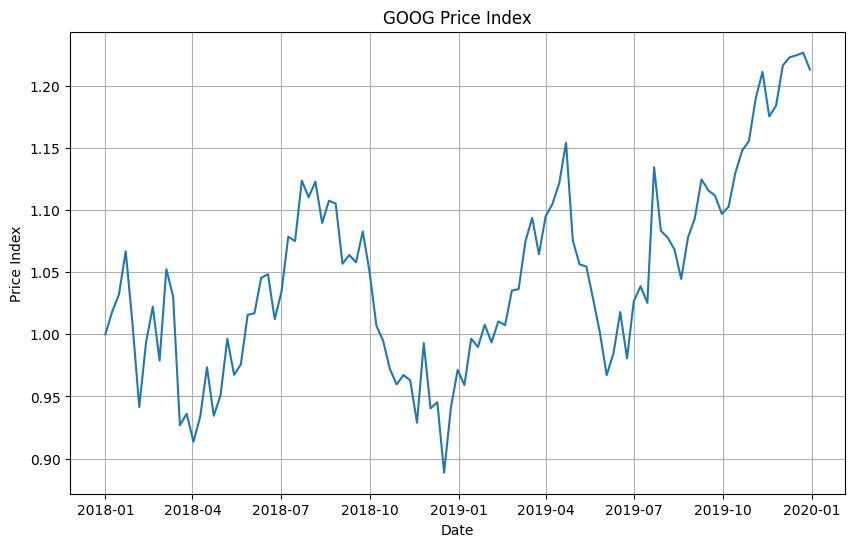

In [3]:
# Plot the level price series
plt.plot(price.index, price.values)
plt.title(f"{series_name} Price Index")
plt.xlabel("Date")
plt.ylabel("Price Index")
plt.grid(True)
plt.show()

The first diagnostic step is the time plot of the equity price series.

A price series that drifts over time and does not fluctuate around a stable mean is often a candidate for nonstationarity.

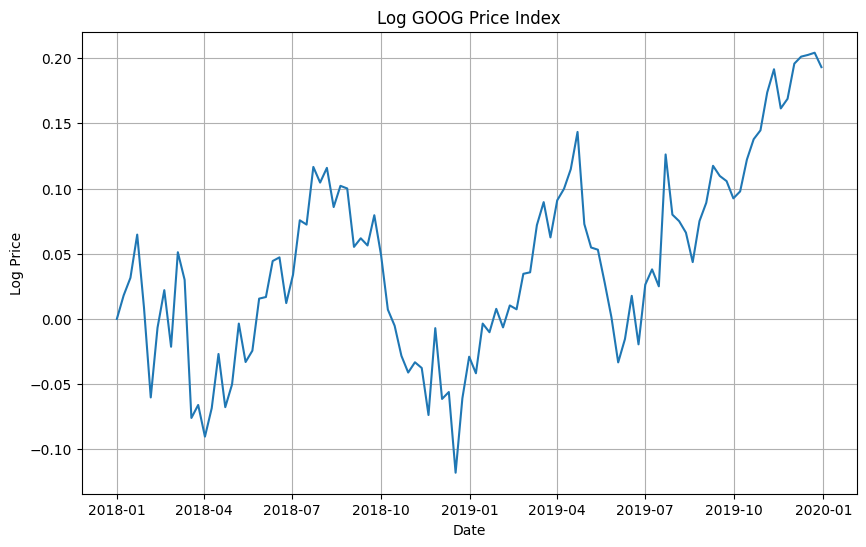

In [4]:
# Construct the log price series
log_price = np.log(price)

plt.plot(log_price.index, log_price.values)
plt.title(f"Log {series_name} Price Index")
plt.xlabel("Date")
plt.ylabel("Log Price")
plt.grid(True)
plt.show()

We work with the log price series

$$
p_t = \log(P_t).
$$

This is standard in financial econometrics because it places multiplicative price changes on an additive scale.

In [5]:
# Helper function to run ADF and KPSS neatly
def unit_root_summary(series, adf_regression="c", kpss_regression="c", name="series"):
    series = pd.Series(series).dropna()

    adf = adfuller(series, regression=adf_regression, autolag="AIC")
    kpss_res = kpss(series, regression=kpss_regression, nlags="auto")

    out = pd.DataFrame({
        "Series": [name],
        "ADF Statistic": [adf[0]],
        "ADF p-value": [adf[1]],
        "ADF Lags": [adf[2]],
        "KPSS Statistic": [kpss_res[0]],
        "KPSS p-value": [kpss_res[1]],
        "KPSS Lags": [kpss_res[2]],
    })

    return out, adf, kpss_res

We use two complementary tests:

- **ADF**: reject for stationarity;
- **KPSS**: reject for nonstationarity.

For the level series, we allow for a deterministic trend by using trend specifications in both tests.

In [6]:
# Test the log level series
level_results, adf_level, kpss_level = unit_root_summary(
    log_price,
    adf_regression="ct",
    kpss_regression="ct",
    name="log_price"
)

level_results

,Series,ADF Statistic,ADF p-value,ADF Lags,KPSS Statistic,KPSS p-value,KPSS Lags
0,log_price,-2.266209,0.452723,1,0.166474,0.032938,5


For the log level series, we test whether the process contains a unit root.

Interpretation logic:

- if the ADF p-value is large, we fail to reject the unit-root null;
- if the KPSS p-value is small, we reject the stationarity null.

If both happen together, the evidence points strongly toward nonstationarity in levels.

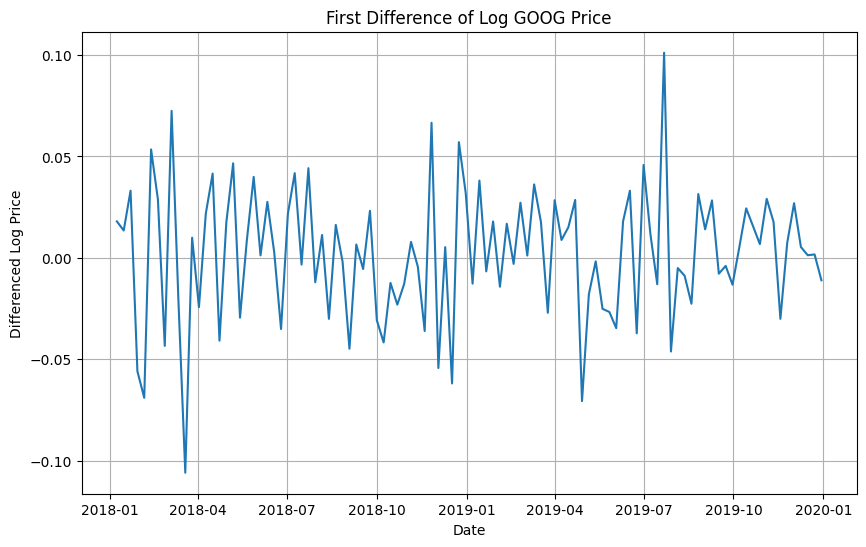

In [7]:
# First difference of the log price series
dlog_price = log_price.diff().dropna()

plt.plot(dlog_price.index, dlog_price.values)
plt.title(f"First Difference of Log {series_name} Price")
plt.xlabel("Date")
plt.ylabel("Differenced Log Price")
plt.grid(True)
plt.show()

If the level series appears nonstationary, the standard remedy is first differencing:

$$
\Delta p_t = p_t - p_{t-1}.
$$

In financial applications, this is closely related to continuously compounded return dynamics.

In [8]:
# Test the differenced log series
diff_results, adf_diff, kpss_diff = unit_root_summary(
    dlog_price,
    adf_regression="c",
    kpss_regression="c",
    name="dlog_price"
)

diff_results

,Series,ADF Statistic,ADF p-value,ADF Lags,KPSS Statistic,KPSS p-value,KPSS Lags
0,dlog_price,-12.498111,2.846187e-23,0,0.094716,0.1,8


For the differenced series, the null-hypothesis interpretation is the same:

- **ADF**: null is a unit root,
- **KPSS**: null is stationarity.

If ADF rejects the unit-root null and KPSS does not reject stationarity, then the differenced series behaves as a stationary process.

In [9]:
# Summarize both test results together
test_summary = pd.concat([level_results, diff_results], ignore_index=True)
test_summary

,Series,ADF Statistic,ADF p-value,ADF Lags,KPSS Statistic,KPSS p-value,KPSS Lags
0,log_price,-2.266209,4.527228e-01,1,0.166474,0.032938,5
1,dlog_price,-12.498111,2.846187e-23,0,0.094716,0.100000,8


This table gives the key empirical answer for **5b**.

If the level series appears nonstationary while the first difference appears stationary, then the equity series is well described as

$$
p_t \sim I(1).
$$

In [10]:
# Programmatic interpretation
print("Interpretation for log price:")
if adf_level[1] < 0.05:
    print("- ADF rejects the unit-root null.")
else:
    print("- ADF fails to reject the unit-root null.")

if kpss_level[1] < 0.05:
    print("- KPSS rejects the stationarity null.")
else:
    print("- KPSS fails to reject the stationarity null.")

print()
print("Interpretation for differenced log price:")
if adf_diff[1] < 0.05:
    print("- ADF rejects the unit-root null.")
else:
    print("- ADF fails to reject the unit-root null.")

if kpss_diff[1] < 0.05:
    print("- KPSS rejects the stationarity null.")
else:
    print("- KPSS fails to reject the stationarity null.")

Interpretation for log price:
- ADF fails to reject the unit-root null.
- KPSS rejects the stationarity null.

Interpretation for differenced log price:
- ADF rejects the unit-root null.
- KPSS fails to reject the stationarity null.


## 5a: What do we do if a unit root is found?

If the level series contains a unit root, then the standard approach is to difference the series once and re-test it.

Mathematically, if

$$
p_t \text{ has a unit root},
$$

we form

$$
\Delta p_t = p_t - p_{t-1}.
$$

If the differenced series is stationary, then the original process is integrated of order one:

$$
p_t \sim I(1).
$$

In financial engineering, this matters because many models assume stationarity in the working series. Regressing or forecasting with a nonstationary level series can lead to misleading inference.

In [11]:
# Simulation settings for 5c
T = 200
seed = 42
rng = np.random.default_rng(seed)
eps = rng.normal(0, 1, T)

# phi = 1 unit-root process
y_unit = np.zeros(T)
for t in range(1, T):
    y_unit[t] = y_unit[t-1] + eps[t]

# phi = 1.5 explosive process
y_explosive = np.zeros(T)
for t in range(1, T):
    y_explosive[t] = 1.5 * y_explosive[t-1] + eps[t]

For **5c**, we simulate two processes using the same innovation sequence:

1. **Unit root**:
   $$
   y_t = y_{t-1} + \varepsilon_t
   $$
2. **Explosive process**:
   $$
   y_t = 1.5\,y_{t-1} + \varepsilon_t
   $$

This helps us understand why the economically important boundary is the unit root, not an obviously explosive root such as $1.5$.

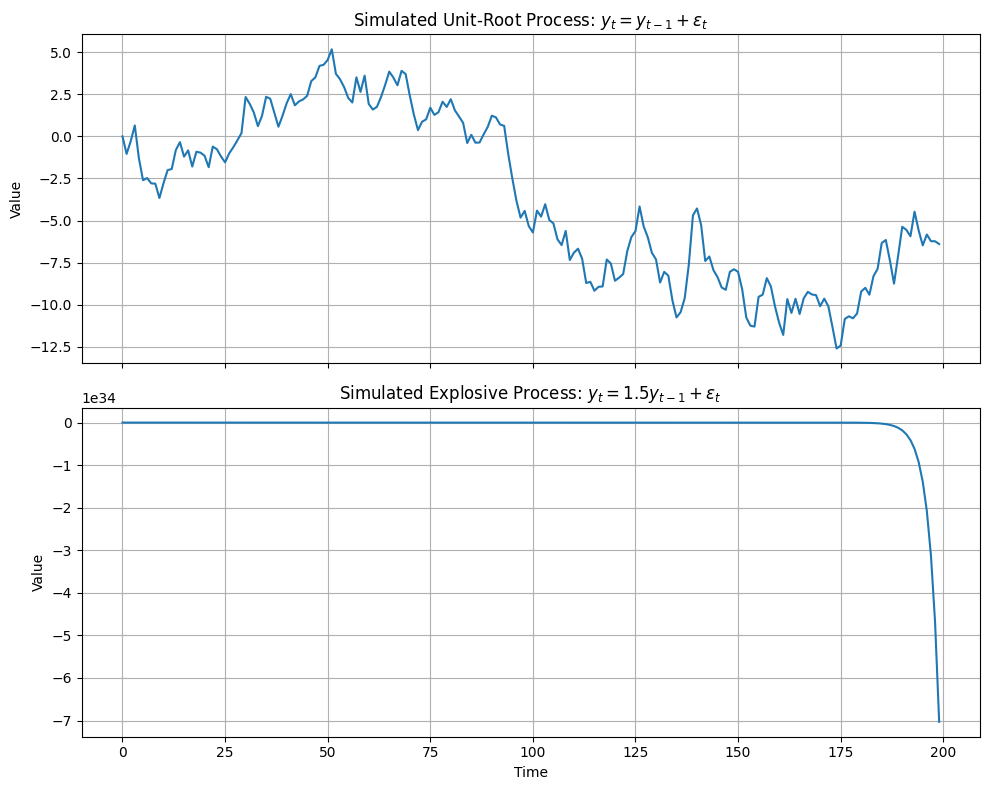

In [12]:
# Plot the two simulated processes
fig, axes = plt.subplots(2, 1, figsize=(10, 8), sharex=True)

axes[0].plot(y_unit)
axes[0].set_title(r"Simulated Unit-Root Process: $y_t = y_{t-1} + \varepsilon_t$")
axes[0].set_ylabel("Value")
axes[0].grid(True)

axes[1].plot(y_explosive)
axes[1].set_title(r"Simulated Explosive Process: $y_t = 1.5y_{t-1} + \varepsilon_t$")
axes[1].set_xlabel("Time")
axes[1].set_ylabel("Value")
axes[1].grid(True)

plt.tight_layout()
plt.show()

The visual comparison in the simulation is the key answer to **5c**:

- when $\phi = 1$, shocks accumulate and the series drifts without mean reversion;
- when $\phi = 1.5$, the process becomes explosive and diverges very rapidly.

This is why financial economics is concerned with the unit-root boundary. The difficult empirical distinction is usually between a stationary but highly persistent process and a true unit-root process, not between a unit root and an obviously explosive process.

In [13]:
# Optional numerical summary for the two simulations
simulation_summary = pd.DataFrame({
    "Process": ["phi = 1", "phi = 1.5"],
    "Final value": [y_unit[-1], y_explosive[-1]],
    "Standard deviation": [np.std(y_unit), np.std(y_explosive)],
    "Maximum absolute value": [np.max(np.abs(y_unit)), np.max(np.abs(y_explosive))]
})

simulation_summary

,Process,Final value,Standard deviation,Maximum absolute value
0,phi = 1,-6.394862e+00,4.861915e+00,1.260130e+01
1,phi = 1.5,-7.028286e+34,6.583745e+33,7.028286e+34


## Final Conclusion

Using a real equity price series, we found that the **log level** behaves like a nonstationary process, while its **first difference** behaves much more like a stationary process. This is consistent with the view that equity price levels are often approximately

$$
I(1).
$$

The simulation study reinforces the point that the economically relevant concern is the unit-root boundary:

$$
\phi = 1,
$$

because it produces persistent random-walk-type behavior. A process with

$$
\phi = 1.5
$$

is explosive and qualitatively different.